In [1]:
import warnings
import numpy as np
from src.modules.generate_ecg import generate_ecg
from src.modules.subfunctions import SimulationParameters
from tqdm import tqdm
import matplotlib.pyplot as plt
from matplotlib.widgets import Slider
import pickle
from itertools import combinations
from concurrent.futures import ThreadPoolExecutor
from functools import partial
import os

warnings.filterwarnings("ignore")

LINE_WIDTH = 2

# Body parameters

In [2]:
R_CHEST = 0.35
R_HIPS = 0.4
R_BELLY = 0.1
A = 8.0
C = 6.0
V0 = -0.1
W = 0.3

# Hearts

In [3]:
N_PHI_HEARTS_LEFT = 7
N_PHI_HEARTS_RIGHT = 4
N_Z_HEARTS = 4
N_R = 2
phi_left_hearts = np.linspace(0, 5 * np.pi / 18, N_PHI_HEARTS_LEFT)
phi_right_hearts = np.linspace(-np.pi / 17, -np.pi / 4, N_PHI_HEARTS_RIGHT)
phi_hearts = np.concatenate([phi_left_hearts, phi_right_hearts])
z_low_hearts = np.linspace(-0.35, -0.07, N_Z_HEARTS)
z_high_hearts = np.array([0, 0.025, 0.04])
z_lin_hearts = np.concatenate([z_low_hearts, z_high_hearts])

d_vals = np.linspace(0.04, 0.11, N_R)
phi_3d, z_3d, d_3d = np.meshgrid(phi_hearts, z_lin_hearts, d_vals, indexing="ij")
R_base_pts = R_CHEST * np.exp(-A * (z_3d - 0.3) ** 2) + R_HIPS * np.exp(
    -C * (z_3d + 0.3) ** 2
)

belly_profile_pts = 1 / (1 + ((z_3d - V0) / W) ** 4)
front_pts = np.maximum(0, np.cos(phi_3d))
belly_pts = R_BELLY * belly_profile_pts * front_pts

R_surface = R_base_pts + belly_pts

R_inner = R_surface - d_3d

R_inner = np.maximum(R_inner, 0)

x_center = 0.1 * np.exp(-10 * (z_3d - V0) ** 2)

x_inner = x_center + R_inner * np.cos(phi_3d)
y_inner = R_inner * np.sin(phi_3d)
z_inner = z_3d
phi_flat = phi_3d.flatten()
R_flat = R_inner.flatten()
z_flat = z_3d.flatten()
points_inner_cyl = np.column_stack((phi_flat, R_flat, z_flat))

# Electrodes

In [ ]:
N_PHI_PTS_LEFT = 6
N_PHI_PTS_RIGHT = 4
N_Z_PTS = 3
z_low_pts = np.linspace(-0.4, -0.1, N_Z_PTS)
z_high_pts = np.array([0, 0.1])
z_lin_pts = np.concatenate([z_low_pts, z_high_pts])
phi_left_pts = np.linspace(0, np.pi / 3, N_PHI_PTS_LEFT)
phi_right_pts = np.linspace(-np.pi / 3, -np.pi / 12, N_PHI_PTS_RIGHT)
phi_pts = np.concatenate([phi_left_pts, phi_right_pts])
phi_pts, z_lin_pts = np.meshgrid(phi_pts, z_lin_pts)
R_base_pts = R_CHEST * np.exp(-A * (z_lin_pts - 0.3) ** 2) + R_HIPS * np.exp(
    -C * (z_lin_pts + 0.3) ** 2
)

belly_profile_pts = 1 / (1 + ((z_lin_pts - V0) / W) ** 4)

front_pts = np.maximum(0, np.cos(phi_pts))
belly_pts = R_BELLY * belly_profile_pts * front_pts

R_pts = R_base_pts + belly_pts

x_pts = R_pts * np.cos(phi_pts)
x_pts += 0.1 * np.exp(-10 * (z_lin_pts - V0) ** 2)
y_pts = R_pts * np.sin(phi_pts)
z_pts = z_lin_pts
x_center = 0.1 * np.exp(-10 * (z_lin_pts - V0) ** 2)
R_true = np.sqrt(x_pts**2 + y_pts**2)
phi_true = np.arctan2(y_pts, x_pts)
phi_flat = phi_true.flatten()
r_flat = R_true.flatten()
z_flat = z_lin_pts.flatten()
points_cyl = np.column_stack((phi_flat, r_flat, z_flat))

# Visualization

In [5]:
%matplotlib widget


def pol2cart(rho, phi, z=None):
    x = rho * np.cos(phi)
    y = rho * np.sin(phi)
    if z is not None:
        return x, y, z
    return x, y


u = np.linspace(0, 2 * np.pi, 120)
v = np.linspace(-0.5, 0.5, 120)
u, v = np.meshgrid(u, v)

R_base = R_CHEST * np.exp(-A * (v - 0.3) ** 2) + R_HIPS * np.exp(-C * (v + 0.3) ** 2)

belly_profile = 1 / (1 + ((v - V0) / W) ** 4)
front = np.maximum(0, np.cos(u))

belly = R_BELLY * belly_profile * front

R = R_base + belly

x = R * np.cos(u)
x += 0.1 * np.exp(-10 * (v - V0) ** 2)
y = R * np.sin(u)
z = v
R_heart = 0.07

# fig = plt.figure()
# ax = fig.add_subplot(111, projection="3d")
# ax.plot_surface(x, y, z, alpha=0.4)

# ax.scatter(x_inner, y_inner, z_inner, s=7, color="k")


# # x, y, z = pol2cart(refpos[1], refpos[0], -0.8)
# # ax.scatter(x, y, z, s=20)
# # ax.text(x, y, z, "R")
# x, y, z = pol2cart(points_cyl[ref][1], points_cyl[ref][0], points_cyl[ref][2])
# ax.scatter(x, y, z, s=10, color="b")

# plt.ion()
# plt.show()

In [6]:
# %matplotlib widget
# with open("data.pkl", "rb") as file:
#     data = pickle.load(file)

# data_test = np.array([np.sum(data[i]).item() for i in range(len(data))])
# x = R * np.cos(u)
# x += 0.1 * np.exp(-10 * (v - V0) ** 2)
# y = R * np.sin(u)
# z = v
# fig = plt.figure()
# ax = fig.add_subplot(111, projection="3d")
# ax.plot_surface(x, y, z, alpha=0.1)

# # ax.scatter(x_inner, y_inner, z_inner, s=7, color="k")
# x, y, z = pol2cart(points_cyl.T[1], points_cyl.T[0], points_cyl.T[2])
# scatter = ax.scatter(x, y, z, s=5, c=data_test, cmap="Reds")
# plt.colorbar(scatter, label="Value Intensity")
# plt.ion()
# plt.show()

# Data generation

In [7]:
FS = 200
TIME = 20
all_mix = []
all_fecg = []
ref = 0
for foetus in tqdm(range(points_inner_cyl.shape[0]), desc="Foetus generation"):
    params = SimulationParameters(
        elpos=points_cyl,
        fheart=[points_inner_cyl[foetus]],
        ntype=np.array([""]),
        SNRmn=6,
        fs=FS,
        n=FS * TIME,
        ftraj=np.array(["none"]),
    )
    out = generate_ecg(params).to_dict()
    all_mix.append(out["mixture"])
    all_fecg.append(out["fecg"][0])

Foetus generation: 100%|██████████| 154/154 [01:49<00:00,  1.40it/s]


Parallel processing:   0%|          | 764/1906884 [00:11<07:49, 4060.39it/s]

In [8]:
def signal_fraction(mix, fecg):
    x = mix - np.mean(mix)
    s = fecg - np.mean(fecg)
    a = np.dot(x, s) / np.dot(s, s)
    cov_xy = np.mean(x * s)
    var_x = np.var(x)
    var_s = np.var(s)
    if var_x == 0 or var_s == 0:
        fraction = 1.0 if np.allclose(x, a * s) else 0
    else:
        r2 = (cov_xy**2) / (var_x * var_s)
        fraction = max(0.0, min(1.0, r2))

    return fraction


def process_comb(comb_ref_id, all_mix, all_fecg, fs):
    scores_across_foetus = []
    for mix, fecg in zip(all_mix, all_fecg):
        diff = mix[comb_ref_id][:-1] - mix[comb_ref_id][-1]

        corr_vals = np.array(
            [
                signal_fraction(diff[i], fecg[comb_ref_id][i])
                for i in range(len(comb_ref_id) - 1)
            ]
        )
        score_current = np.max(corr_vals)
        scores_across_foetus.append(score_current)

    pair_score = np.mean(scores_across_foetus)
    return (pair_score, comb_ref_id)

In [9]:
def main_parallel(fs, all_mix, all_fecg, comb_ref):
    with ThreadPoolExecutor(max_workers=(os.process_cpu_count() or 1) + 4) as executor:
        func = partial(process_comb, all_mix=all_mix, all_fecg=all_fecg, fs=fs)
        results = list(
            tqdm(
                executor.map(func, comb_ref),
                total=len(comb_ref),
                desc="Parallel processing",
            )
        )
        return results

In [10]:
# combs = list(combinations(range(1, points_cyl.shape[0]), 5))
# ref = 0
# comb_ref = []
# for comb in combs:
#     comb_ref.append([*comb, ref])

# results = main_parallel(fs=FS, all_mix=all_mix, all_fecg=all_fecg, comb_ref=comb_ref)
# y_data = []
# for i in range(len(comb_ref)):
#     y_data.append(results[i][0].item())

# y_data = np.array(y_data)

In [11]:
# max(y_data)

In [12]:
# %matplotlib widget

# mask = (y_data > 0.555) & (y_data < 0.57)
# plot_combs = np.array(comb_ref)[mask]

# initial_index = 0
# x = R * np.cos(u)
# x += 0.1 * np.exp(-10 * (v - V0) ** 2)
# y = R * np.sin(u)
# z = v
# fig = plt.figure()
# ax = fig.add_subplot(111, projection="3d")
# ax.plot_surface(x, y, z, alpha=0.1)

# ax_slider = plt.axes([0.2, 0.08, 0.6, 0.03])
# index_slider = Slider(
#     ax=ax_slider,
#     label="Combination №: ",
#     valmin=0,
#     valmax=len(plot_combs) - 1,
#     valinit=initial_index,
#     valstep=1,
# )
# colors = ["green", "green", "green", "green", "blue"]

# phi_init, r_init, z_init = points_cyl[plot_combs[initial_index]].T
# x_init, y_init, z_init = pol2cart(r_init, phi_init, z_init)
# scatter = ax.scatter(x_init, y_init, z_init, s=10, color=colors)


# def update(val):
#     global scatter
#     scatter.remove()
#     idx = int(index_slider.val)

#     phi, r, z = points_cyl[plot_combs[idx]].T
#     x, y, z = pol2cart(r, phi, z)
#     scatter = ax.scatter(x, y, z, s=10, color=colors)

#     fig.canvas.draw_idle()


# index_slider.on_changed(update)


# def on_key(event):
#     current_val = index_slider.val

#     if event.key == "right":
#         if current_val < index_slider.valmax:
#             index_slider.set_val(current_val + 1)

#     elif event.key == "left":
#         if current_val > index_slider.valmin:
#             index_slider.set_val(current_val - 1)


# fig.canvas.mpl_connect("key_press_event", on_key)

# plt.show()

In [13]:
# combs_3 = list(combinations(range(1, points_cyl.shape[0]), 2))
# ref = 0
# comb_ref_3 = []
# for comb in combs_3:
#     comb_ref_3.append([*comb, ref])

# if __name__ == "__main__":
#     results_3 = main_parallel(
#         fs=FS, all_mix=all_mix, all_fecg=all_fecg, comb_ref=comb_ref_3
#     )

# y_data_3 = []
# for i in range(len(comb_ref_3)):
#     y_data_3.append(results_3[i][0].item())

# y_data_3 = np.array(y_data_3)

In [14]:
# mask_3 = (y_data_3 > 0.421) & (y_data_3 < 0.44)
# plot_combs_3 = np.array(comb_ref_3)[mask_3]

# initial_index = 0
# x = R * np.cos(u)
# x += 0.1 * np.exp(-10 * (v - V0) ** 2)
# y = R * np.sin(u)
# z = v
# fig_3 = plt.figure()
# ax_3 = fig_3.add_subplot(111, projection="3d")
# ax_3.plot_surface(x, y, z, alpha=0.1)

# ax_slider_3 = plt.axes([0.2, 0.08, 0.6, 0.03])
# index_slider_3 = Slider(
#     ax=ax_slider_3,
#     label="Combination №: ",
#     valmin=0,
#     valmax=len(plot_combs_3) - 1,
#     valinit=initial_index,
#     valstep=1,
# )
# colors = ["green", "green", "blue"]

# phi_init, r_init, z_init = points_cyl[plot_combs_3[initial_index]].T
# x_init, y_init, z_init = pol2cart(r_init, phi_init, z_init)
# scatter_3 = ax_3.scatter(x_init, y_init, z_init, s=10, color=colors)


# def update(val):
#     global scatter_3
#     scatter_3.remove()
#     idx = int(index_slider_3.val)

#     phi, r, z = points_cyl[plot_combs_3[idx]].T
#     x, y, z = pol2cart(r, phi, z)
#     scatter_3 = ax_3.scatter(x, y, z, s=10, color=colors)

#     fig_3.canvas.draw_idle()


# index_slider_3.on_changed(update)


# def on_key(event):
#     current_val = index_slider_3.val

#     if event.key == "right":
#         if current_val < index_slider_3.valmax:
#             index_slider_3.set_val(current_val + 1)

#     elif event.key == "left":
#         if current_val > index_slider_3.valmin:
#             index_slider_3.set_val(current_val - 1)


# fig_3.canvas.mpl_connect("key_press_event", on_key)

# plt.show()

In [15]:
combs_4 = list(combinations(range(1, points_cyl.shape[0]), 3))
ref = 0
comb_ref_4 = []
for comb in combs_4:
    comb_ref_4.append([*comb, ref])

results_4 = main_parallel(
    fs=FS, all_mix=all_mix, all_fecg=all_fecg, comb_ref=comb_ref_4
)

y_data_4 = []
for i in range(len(comb_ref_4)):
    y_data_4.append(results_4[i][0].item())

y_data_4 = np.array(y_data_4)

Parallel processing: 100%|██████████| 18424/18424 [05:37<00:00, 54.53it/s] 


In [16]:
# mask_4 = (y_data_4 > 0.5) & (y_data_4 < 0.51)
# plot_combs_4 = np.array(comb_ref_4)[mask_4]

# initial_index = 0
# x = R * np.cos(u)
# x += 0.1 * np.exp(-10 * (v - V0) ** 2)
# y = R * np.sin(u)
# z = v
# fig_4 = plt.figure()
# ax_4 = fig_4.add_subplot(111, projection="3d")
# ax_4.plot_surface(x, y, z, alpha=0.1)

# ax_slider_4 = plt.axes([0.2, 0.08, 0.6, 0.03])
# index_slider_4 = Slider(
#     ax=ax_slider_4,
#     label="Combination №: ",
#     valmin=0,
#     valmax=len(plot_combs_4) - 1,
#     valinit=initial_index,
#     valstep=1,
# )

# colors = ["green", "green", "green", "blue"]
# phi_init, r_init, z_init = points_cyl[plot_combs_4[initial_index]].T
# x_init, y_init, z_init = pol2cart(r_init, phi_init, z_init)
# scatter_4 = ax_4.scatter(x_init, y_init, z_init, s=10, color=colors)


# def update(val):
#     global scatter_4
#     scatter_4.remove()
#     idx = int(index_slider_4.val)

#     phi, r, z = points_cyl[plot_combs_4[idx]].T
#     x, y, z = pol2cart(r, phi, z)
#     scatter_4 = ax_4.scatter(x, y, z, s=10, color=colors)

#     fig_4.canvas.draw_idle()


# index_slider_4.on_changed(update)


# def on_key(event):
#     current_val = index_slider_4.val

#     if event.key == "right":
#         if current_val < index_slider_4.valmax:
#             index_slider_4.set_val(current_val + 1)

#     elif event.key == "left":
#         if current_val > index_slider_4.valmin:
#             index_slider_4.set_val(current_val - 1)


# fig_4.canvas.mpl_connect("key_press_event", on_key)

# plt.show()

In [17]:
comb_mov_3 = list(combinations(range(points_cyl.shape[0]), 2))

comb_ref_mov_3 = []
for comb in comb_mov_3:
    for ref in range(points_cyl.shape[0]):
        if ref in comb:
            continue
        comb_ref_mov_3.append([*comb, ref])

results_mov_3 = main_parallel(
    fs=FS, all_mix=all_mix, all_fecg=all_fecg, comb_ref=comb_ref_mov_3
)

y_data_mov_3 = []
for i in range(len(comb_ref_mov_3)):
    y_data_mov_3.append(results_mov_3[i][0].item())

y_data_mov_3 = np.array(y_data_mov_3)

Parallel processing: 100%|██████████| 58800/58800 [12:01<00:00, 81.45it/s]  


In [18]:
# mask_mov_3 = (y_data_mov_3 > 0.43) & (y_data_mov_3 < 0.44)
# plot_combs_mov_3 = np.array(comb_ref_mov_3)[mask_mov_3]

# initial_index = 0
# x = R * np.cos(u)
# x += 0.1 * np.exp(-10 * (v - V0) ** 2)
# y = R * np.sin(u)
# z = v
# fig_mov_3 = plt.figure()
# ax_mov_3 = fig_mov_3.add_subplot(111, projection="3d")
# ax_mov_3.plot_surface(x, y, z, alpha=0.1)

# ax_slider_mov_3 = plt.axes([0.2, 0.08, 0.6, 0.03])
# index_slider_mov_3 = Slider(
#     ax=ax_slider_mov_3,
#     label="Combination №: ",
#     valmin=0,
#     valmax=len(plot_combs_mov_3) - 1,
#     valinit=initial_index,
#     valstep=1,
# )

# colors = ["green", "green", "blue"]
# phi_init, r_init, z_init = points_cyl[plot_combs_mov_3[initial_index]].T
# x_init, y_init, z_init = pol2cart(r_init, phi_init, z_init)
# scatter_mov_3 = ax_mov_3.scatter(x_init, y_init, z_init, s=10, color=colors)


# def update(val):
#     global scatter_mov_3
#     scatter_mov_3.remove()
#     idx = int(index_slider_mov_3.val)

#     phi, r, z = points_cyl[plot_combs_mov_3[idx]].T
#     x, y, z = pol2cart(r, phi, z)
#     scatter_mov_3 = ax_mov_3.scatter(x, y, z, s=10, color=colors)

#     fig_mov_3.canvas.draw_idle()


# index_slider_mov_3.on_changed(update)


# def on_key(event):
#     current_val = index_slider_mov_3.val

#     if event.key == "right":
#         if current_val < index_slider_mov_3.valmax:
#             index_slider_mov_3.set_val(current_val + 1)

#     elif event.key == "left":
#         if current_val > index_slider_mov_3.valmin:
#             index_slider_mov_3.set_val(current_val - 1)


# fig_mov_3.canvas.mpl_connect("key_press_event", on_key)

# plt.show()

In [19]:
# comb_mov_4 = list(combinations(range(points_cyl.shape[0]), 3))

# comb_ref_mov_4 = []
# for comb in comb_mov_4:
#     for ref in range(points_cyl.shape[0]):
#         if ref in comb:
#             continue
#         comb_ref_mov_4.append([*comb, ref])

# results_mov_4 = main_parallel(
#     fs=FS, all_mix=all_mix, all_fecg=all_fecg, comb_ref=comb_ref_mov_4
# )

# y_data_mov_4 = []
# for i in range(len(comb_ref_mov_4)):
#     y_data_mov_4.append(results_mov_4[i][0].item())

# y_data_mov_4 = np.array(y_data_mov_4)

In [20]:
# mask_mov_4 = (y_data_mov_4 > 0.504) & (y_data_mov_4 < 0.51)
# plot_combs_mov_4 = np.array(comb_ref_mov_4)[mask_mov_4]

# initial_index = 0
# x = R * np.cos(u)
# x += 0.1 * np.exp(-10 * (v - V0) ** 2)
# y = R * np.sin(u)
# z = v
# fig_mov_4 = plt.figure()
# ax_mov_4 = fig_mov_4.add_subplot(111, projection="3d")
# ax_mov_4.plot_surface(x, y, z, alpha=0.1)


# ax_slider_mov_4 = plt.axes([0.2, 0.08, 0.6, 0.03])
# index_slider_mov_4 = Slider(
#     ax=ax_slider_mov_4,
#     label="Combination №: ",
#     valmin=0,
#     valmax=len(plot_combs_mov_4) - 1,
#     valinit=initial_index,
#     valstep=1,
# )


# colors = ["green", "green", "green", "blue"]
# phi_init, r_init, z_init = points_cyl[plot_combs_mov_4[initial_index]].T
# x_init, y_init, z_init = pol2cart(r_init, phi_init, z_init)
# scatter_mov_4 = ax_mov_4.scatter(x_init, y_init, z_init, s=10, color=colors)


# def update(val):
#     global scatter_mov_4
#     scatter_mov_4.remove()
#     idx = int(index_slider_mov_4.val)

#     phi, r, z = points_cyl[plot_combs_mov_4[idx]].T
#     x, y, z = pol2cart(r, phi, z)
#     scatter_mov_4 = ax_mov_4.scatter(x, y, z, s=10, color=colors)

#     fig_mov_4.canvas.draw_idle()


# index_slider_mov_4.on_changed(update)


# def on_key(event):
#     current_val = index_slider_mov_4.val

#     if event.key == "right":
#         if current_val < index_slider_mov_4.valmax:
#             index_slider_mov_4.set_val(current_val + 1)

#     elif event.key == "left":
#         if current_val > index_slider_mov_4.valmin:
#             index_slider_mov_4.set_val(current_val - 1)


# fig_mov_4.canvas.mpl_connect("key_press_event", on_key)

# plt.show()

In [31]:
comb_mov_5 = list(combinations(range(1, points_cyl.shape[0]), 4))
ref = 0
comb_ref_mov_5 = []
for comb in comb_mov_5:
    comb_ref_mov_5.append([*comb, ref])

In [32]:
results_mov_5 = main_parallel(
    fs=FS, all_mix=all_mix, all_fecg=all_fecg, comb_ref=comb_ref_mov_5
)

Parallel processing: 100%|██████████| 211876/211876 [1:23:41<00:00, 42.20it/s]  


(array([   2.,    0.,    6.,    4.,    4.,   11.,   19.,   23.,   21.,
          35.,   62.,   69.,  116.,  134.,  215.,  257.,  350.,  359.,
         411.,  564.,  637.,  706.,  866.,  975., 1106., 1196., 1236.,
        1325., 1387., 1252., 1193., 1127.,  891.,  706.,  531.,  340.,
         166.,   80.,   33.,    9.]),
 array([0.08538484, 0.09547437, 0.10556389, 0.11565342, 0.12574295,
        0.13583247, 0.145922  , 0.15601153, 0.16610105, 0.17619058,
        0.18628011, 0.19636963, 0.20645916, 0.21654869, 0.22663821,
        0.23672774, 0.24681727, 0.25690679, 0.26699632, 0.27708584,
        0.28717537, 0.2972649 , 0.30735442, 0.31744395, 0.32753348,
        0.337623  , 0.34771253, 0.35780206, 0.36789158, 0.37798111,
        0.38807064, 0.39816016, 0.40824969, 0.41833922, 0.42842874,
        0.43851827, 0.4486078 , 0.45869732, 0.46878685, 0.47887638,
        0.4889659 ]),
 <BarContainer object of 40 artists>)

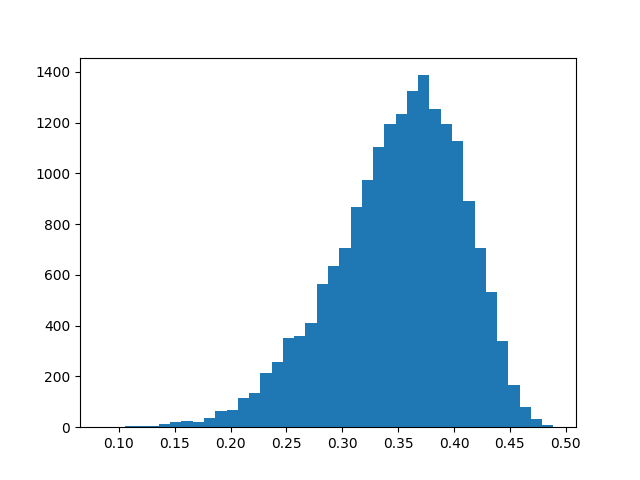

In [42]:
fig_plot, ax_plot = plt.subplots()

ax_plot.hist(y_data_4, bins=40)

In [39]:
y_data_mov_5 = []
for i in range(len(comb_ref_mov_5)):
    y_data_mov_5.append(results_mov_5[i][0].item())

y_data_mov_5 = np.array(y_data_mov_5)

In [24]:
# mask_mov_5 = y_data_mov_5 > 0.54
# plot_combs_mov_5 = np.array(comb_ref_mov_5)[mask_mov_5]

# initial_index = 0
# x = R * np.cos(u)
# x += 0.1 * np.exp(-10 * (v - V0) ** 2)
# y = R * np.sin(u)
# z = v
# fig_mov_5 = plt.figure()
# ax_mov_5 = fig_mov_5.add_subplot(111, projection="3d")
# ax_mov_5.plot_surface(x, y, z, alpha=0.1)

# colors = [
#     "green",
#     "green",
#     "green",
#     "green",
#     "blue",
# ]

# ax_slider_mov_5 = plt.axes([0.2, 0.08, 0.6, 0.03])
# index_slider_mov_5 = Slider(
#     ax=ax_slider_mov_5,
#     label="Combination №: ",
#     valmin=0,
#     valmax=len(plot_combs_mov_5) - 1,
#     valinit=initial_index,
#     valstep=1,
# )


# phi_init, r_init, z_init = points_cyl[plot_combs_mov_5[initial_index]].T
# x_init, y_init, z_init = pol2cart(r_init, phi_init, z_init)
# scatter_mov_5 = ax_mov_5.scatter(x_init, y_init, z_init, s=10, color=colors)


# def update(val):
#     global scatter_mov_5
#     scatter_mov_5.remove()
#     idx = int(index_slider_mov_5.val)

#     phi, r, z = points_cyl[plot_combs_mov_5[idx]].T
#     x, y, z = pol2cart(r, phi, z)
#     scatter_mov_5 = ax_mov_5.scatter(x, y, z, s=10, color=colors)

#     fig_mov_5.canvas.draw_idle()


# index_slider_mov_5.on_changed(update)


# def on_key(event):
#     current_val = index_slider_mov_5.val

#     if event.key == "right":
#         if current_val < index_slider_mov_5.valmax:
#             index_slider_mov_5.set_val(current_val + 1)

#     elif event.key == "left":
#         if current_val > index_slider_mov_5.valmin:
#             index_slider_mov_5.set_val(current_val - 1)


# fig_mov_5.canvas.mpl_connect("key_press_event", on_key)

# plt.show()

In [ ]:
comb_mov_6 = list(combinations(range(1, points_cyl.shape[0]), 5))
ref = 0
comb_ref_mov_6 = []
for comb in comb_mov_6:
    comb_ref_mov_6.append([*comb, ref])

results_mov_6 = main_parallel(
    fs=FS, all_mix=all_mix, all_fecg=all_fecg, comb_ref=comb_ref_mov_6
)


Parallel processing: 100%|██████████| 1906884/1906884 [16:51:04<00:00, 31.43it/s]   


In [26]:
y_data_mov_6 = []
for i in range(len(comb_ref_mov_6)):
    y_data_mov_6.append(results_mov_6[i][0].item())

y_data_mov_6 = np.array(y_data_mov_6)

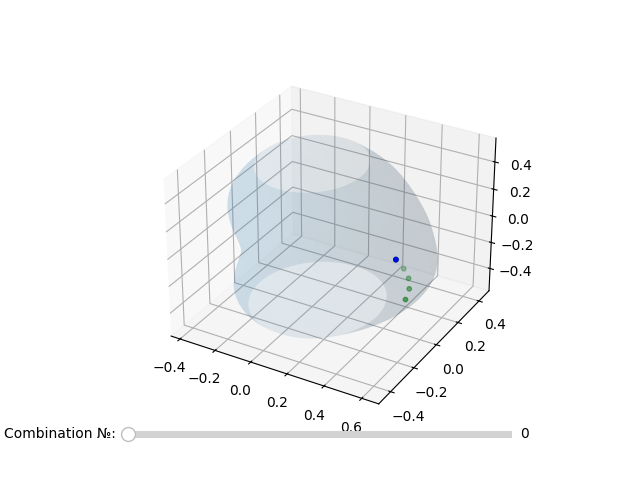

In [27]:
mask_mov_6 = y_data_mov_6 > 0.55
plot_combs_mov_6 = np.array(comb_ref_mov_6)[mask_mov_6]

initial_index = 0
x = R * np.cos(u)
x += 0.1 * np.exp(-10 * (v - V0) ** 2)
y = R * np.sin(u)
z = v
fig_mov_6 = plt.figure()
ax_mov_6 = fig_mov_6.add_subplot(111, projection="3d")
ax_mov_6.plot_surface(x, y, z, alpha=0.1)

colors = [
    "green",
    "green",
    "green",
    "green",
    "green",
    "blue",
]

ax_slider_mov_6 = plt.axes([0.2, 0.08, 0.6, 0.03])
index_slider_mov_6 = Slider(
    ax=ax_slider_mov_6,
    label="Combination №: ",
    valmin=0,
    valmax=len(plot_combs_mov_6) - 1,
    valinit=initial_index,
    valstep=1,
)


phi_init, r_init, z_init = points_cyl[plot_combs_mov_6[initial_index]].T
x_init, y_init, z_init = pol2cart(r_init, phi_init, z_init)
scatter_mov_6 = ax_mov_6.scatter(x_init, y_init, z_init, s=10, color=colors)


def update(val):
    global scatter_mov_6
    scatter_mov_6.remove()
    idx = int(index_slider_mov_6.val)

    phi, r, z = points_cyl[plot_combs_mov_6[idx]].T
    x, y, z = pol2cart(r, phi, z)
    scatter_mov_6 = ax_mov_6.scatter(x, y, z, s=10, color=colors)

    fig_mov_6.canvas.draw_idle()


index_slider_mov_6.on_changed(update)


def on_key(event):
    current_val = index_slider_mov_6.val

    if event.key == "right":
        if current_val < index_slider_mov_6.valmax:
            index_slider_mov_6.set_val(current_val + 1)

    elif event.key == "left":
        if current_val > index_slider_mov_6.valmin:
            index_slider_mov_6.set_val(current_val - 1)


fig_mov_6.canvas.mpl_connect("key_press_event", on_key)

plt.show()